The Analysis is about a Cars .


In [1]:
#!pip install pandas
#!pip install seaborn
#!pip install numpy


In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#df = pd.read_csv(r'E:\University Study\2nd YEAR 1ST SEM\PythonProject\Automobile_data.csv')
df = pd.read_csv("Automobile_data.csv")
df = df.iloc[:, 1:]  # drop first column

df.head()
data = df
df.head()


,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


This code converts the city-mpg and highway-mpg columns to numeric values, replacing any invalid entries with NaN.
Missing values are then filled with the column mean to ensure 

In [3]:
# Convert column to numeric and handling error

df['city-mpg'] = pd.to_numeric(df['city-mpg'], errors='coerce')
df['highway-mpg'] = pd.to_numeric(df['highway-mpg'], errors='coerce')

# missing value fill with mean value for upcoming use

df['city-mpg'] = df['city-mpg'].fillna(df['city-mpg'].mean())
df['highway-mpg'] = df['highway-mpg'].fillna(df['highway-mpg'].mean())

# Group by fuel-type and calculate average MPG
mpg_avg = df.groupby('fuel-type')[['city-mpg','highway-mpg']].mean()
print(mpg_avg)



           city-mpg  highway-mpg
fuel-type                       
diesel     30.30000    34.750000
gas        24.67027    30.318919


COMPARING AVERAGE MPG BETWEEN CITY AND HIGHWAY BY FUEL TYPE 

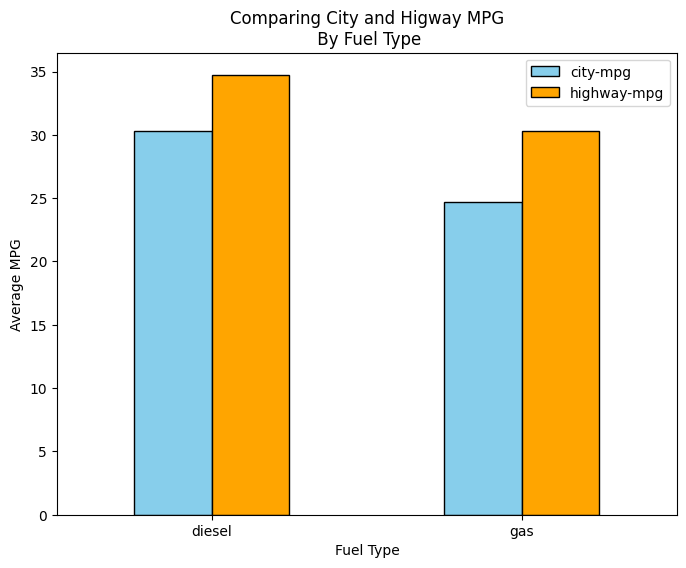

In [4]:
# Plotting average MPG by fuel-type
mpg_avg.plot(kind='bar', figsize=(8,6), color=['skyblue','orange'], edgecolor='black')
plt.title("Comparing City and Higway MPG\n By Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average MPG")
plt.xticks(rotation=0)
plt.show()

FILTERING INVALID ENTRY 
CONVERT PRICE AS INTEGER TYPE

In [5]:
data['city-mpg'] = 235 / df['city-mpg']
data.rename(columns = {'city_mpg': "city-L / 100km"}, inplace = True)
data.price.unique()
data = data[data.price != '?']
data['price'] = data['price'].astype(int)
print(data.columns)
data.dtypes

Index(['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')


C:\Users\pallab\AppData\Local\Temp\ipykernel_10836\2438281536.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price'] = data['price'].astype(int)


normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg             float64
highway-mpg            int64
price                  int64
dtype: object

3         Low
4      Medium
6      Medium
8      Medium
10     Medium
        ...  
200    Medium
201    Medium
202    Medium
203    Medium
204    Medium
Name: price-binned, Length: 159, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


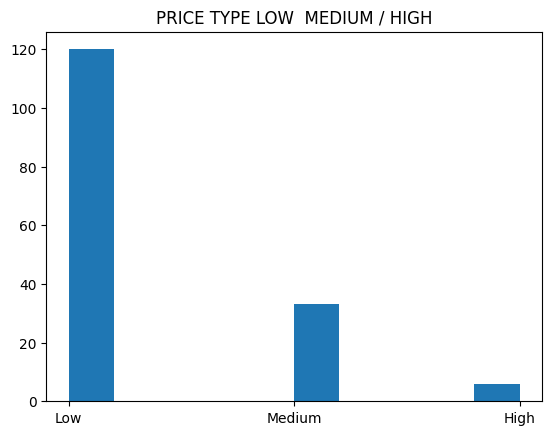

In [22]:
data['length'] = data['length']/data['length'].max()
data['width'] = data['width']/data['width'].max()
data['height'] = data['height']/data['height'].max()

# binning- grouping values
bins = np.linspace(min(data['price']), max(data['price']), 4) 
group_names = ['Low', 'Medium', 'High']
data['price-binned'] = pd.cut(data['price'], bins, 
                              labels = group_names, 
                              include_lowest = True)

print(data['price-binned'])
plt.hist(data['price-binned'])
plt.title("PRICE TYPE LOW  MEDIUM / HIGH")
plt.show();

In [7]:
pd.get_dummies(data['fuel-type']).head()

data.describe()

,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,98.797015,0.837102,0.915126,0.899108,2555.666667,126.875622,10.164279,9.944145,30.686567,13207.129353
std,6.066366,0.059213,0.029187,0.040933,517.296727,41.546834,4.004965,2.534599,6.815150,7947.066342
min,86.600000,0.678039,0.837500,0.799331,1488.000000,61.000000,7.000000,4.795918,16.000000,5118.000000
25%,94.500000,0.801538,0.890278,0.869565,2169.000000,98.000000,8.600000,7.833333,25.000000,7775.000000
50%,97.000000,0.832292,0.909722,0.904682,2414.000000,120.000000,9.000000,9.791667,30.000000,10295.000000
75%,102.400000,0.881788,0.925000,0.928094,2926.000000,141.000000,9.400000,12.368421,34.000000,16500.000000
max,120.900000,1.000000,1.000000,1.000000,4066.000000,326.000000,23.000000,18.076923,54.000000,45400.000000


<Axes: xlabel='drive-wheels', ylabel='price'>

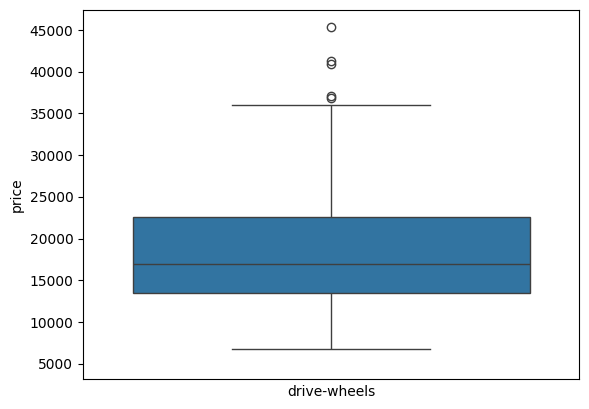

In [8]:
plt.boxplot(data['price'])

sns.boxplot(x ='drive-wheels', y ='price', data = data)

COMPARING PRICE ACCORDING TO ENGINE SIZE


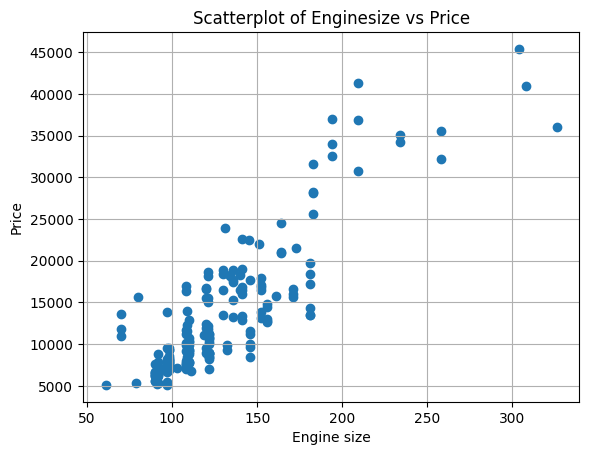

In [9]:
plt.scatter(data['engine-size'], data['price'])
plt.title('Scatterplot of Enginesize vs Price')
plt.xlabel('Engine size')
plt.ylabel('Price')
plt.grid()
plt.show()

In [10]:
test = data[['num-of-cylinders', 'body-style', 'price']]
data_grp = test.groupby(['num-of-cylinders', 'body-style'], 
                         as_index = False).mean()

data_grp

,num-of-cylinders,body-style,price
0,eight,convertible,35056.000000
1,eight,hardtop,45400.000000
2,eight,sedan,37572.000000
3,five,hardtop,28176.000000
4,five,sedan,20676.000000
5,five,wagon,23584.000000
6,four,convertible,14814.750000
7,four,hardtop,9384.000000
8,four,hatchback,9044.245614
9,four,sedan,10891.591549


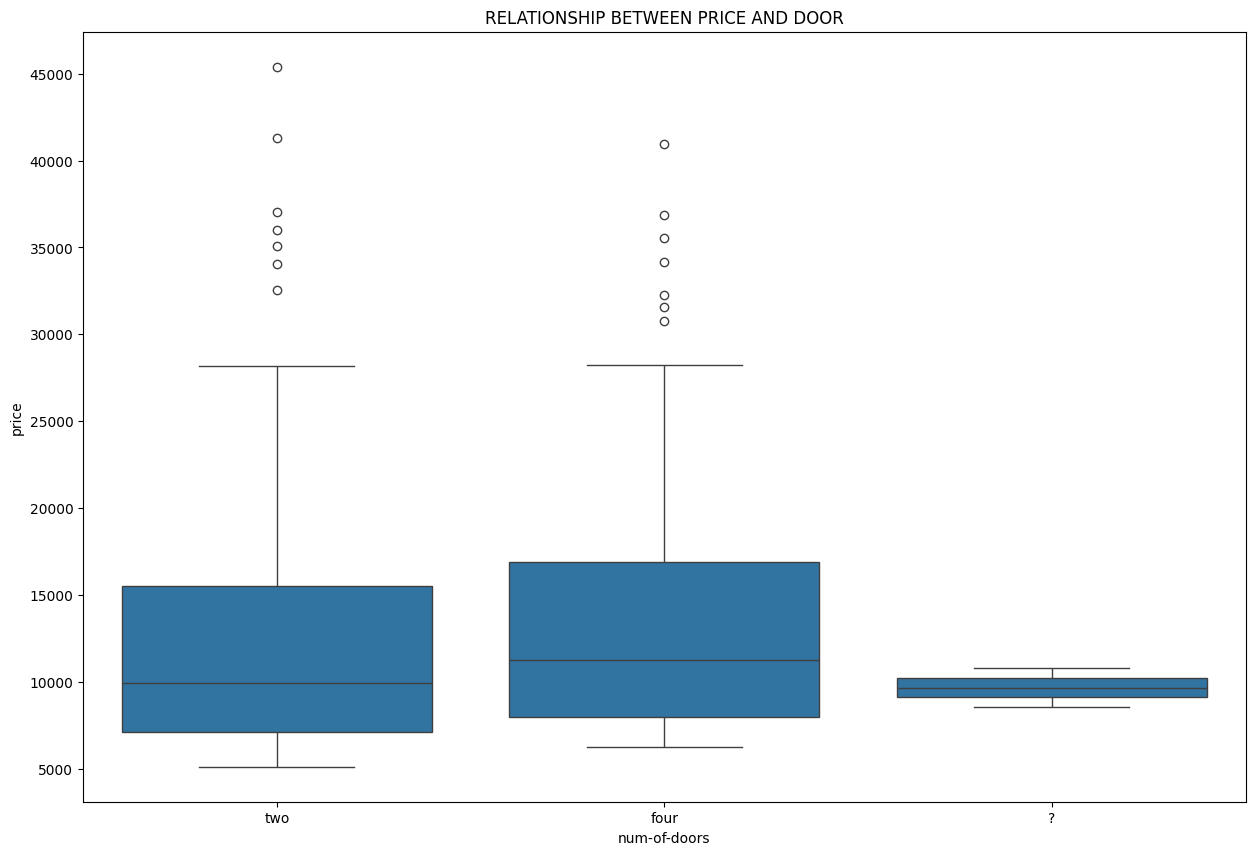

In [11]:
plt.figure(figsize=(15,10))
sns.boxplot(x='num-of-doors', y='price', data=data)
plt.title("RELATIONSHIP BETWEEN PRICE AND DOOR")
plt.show()

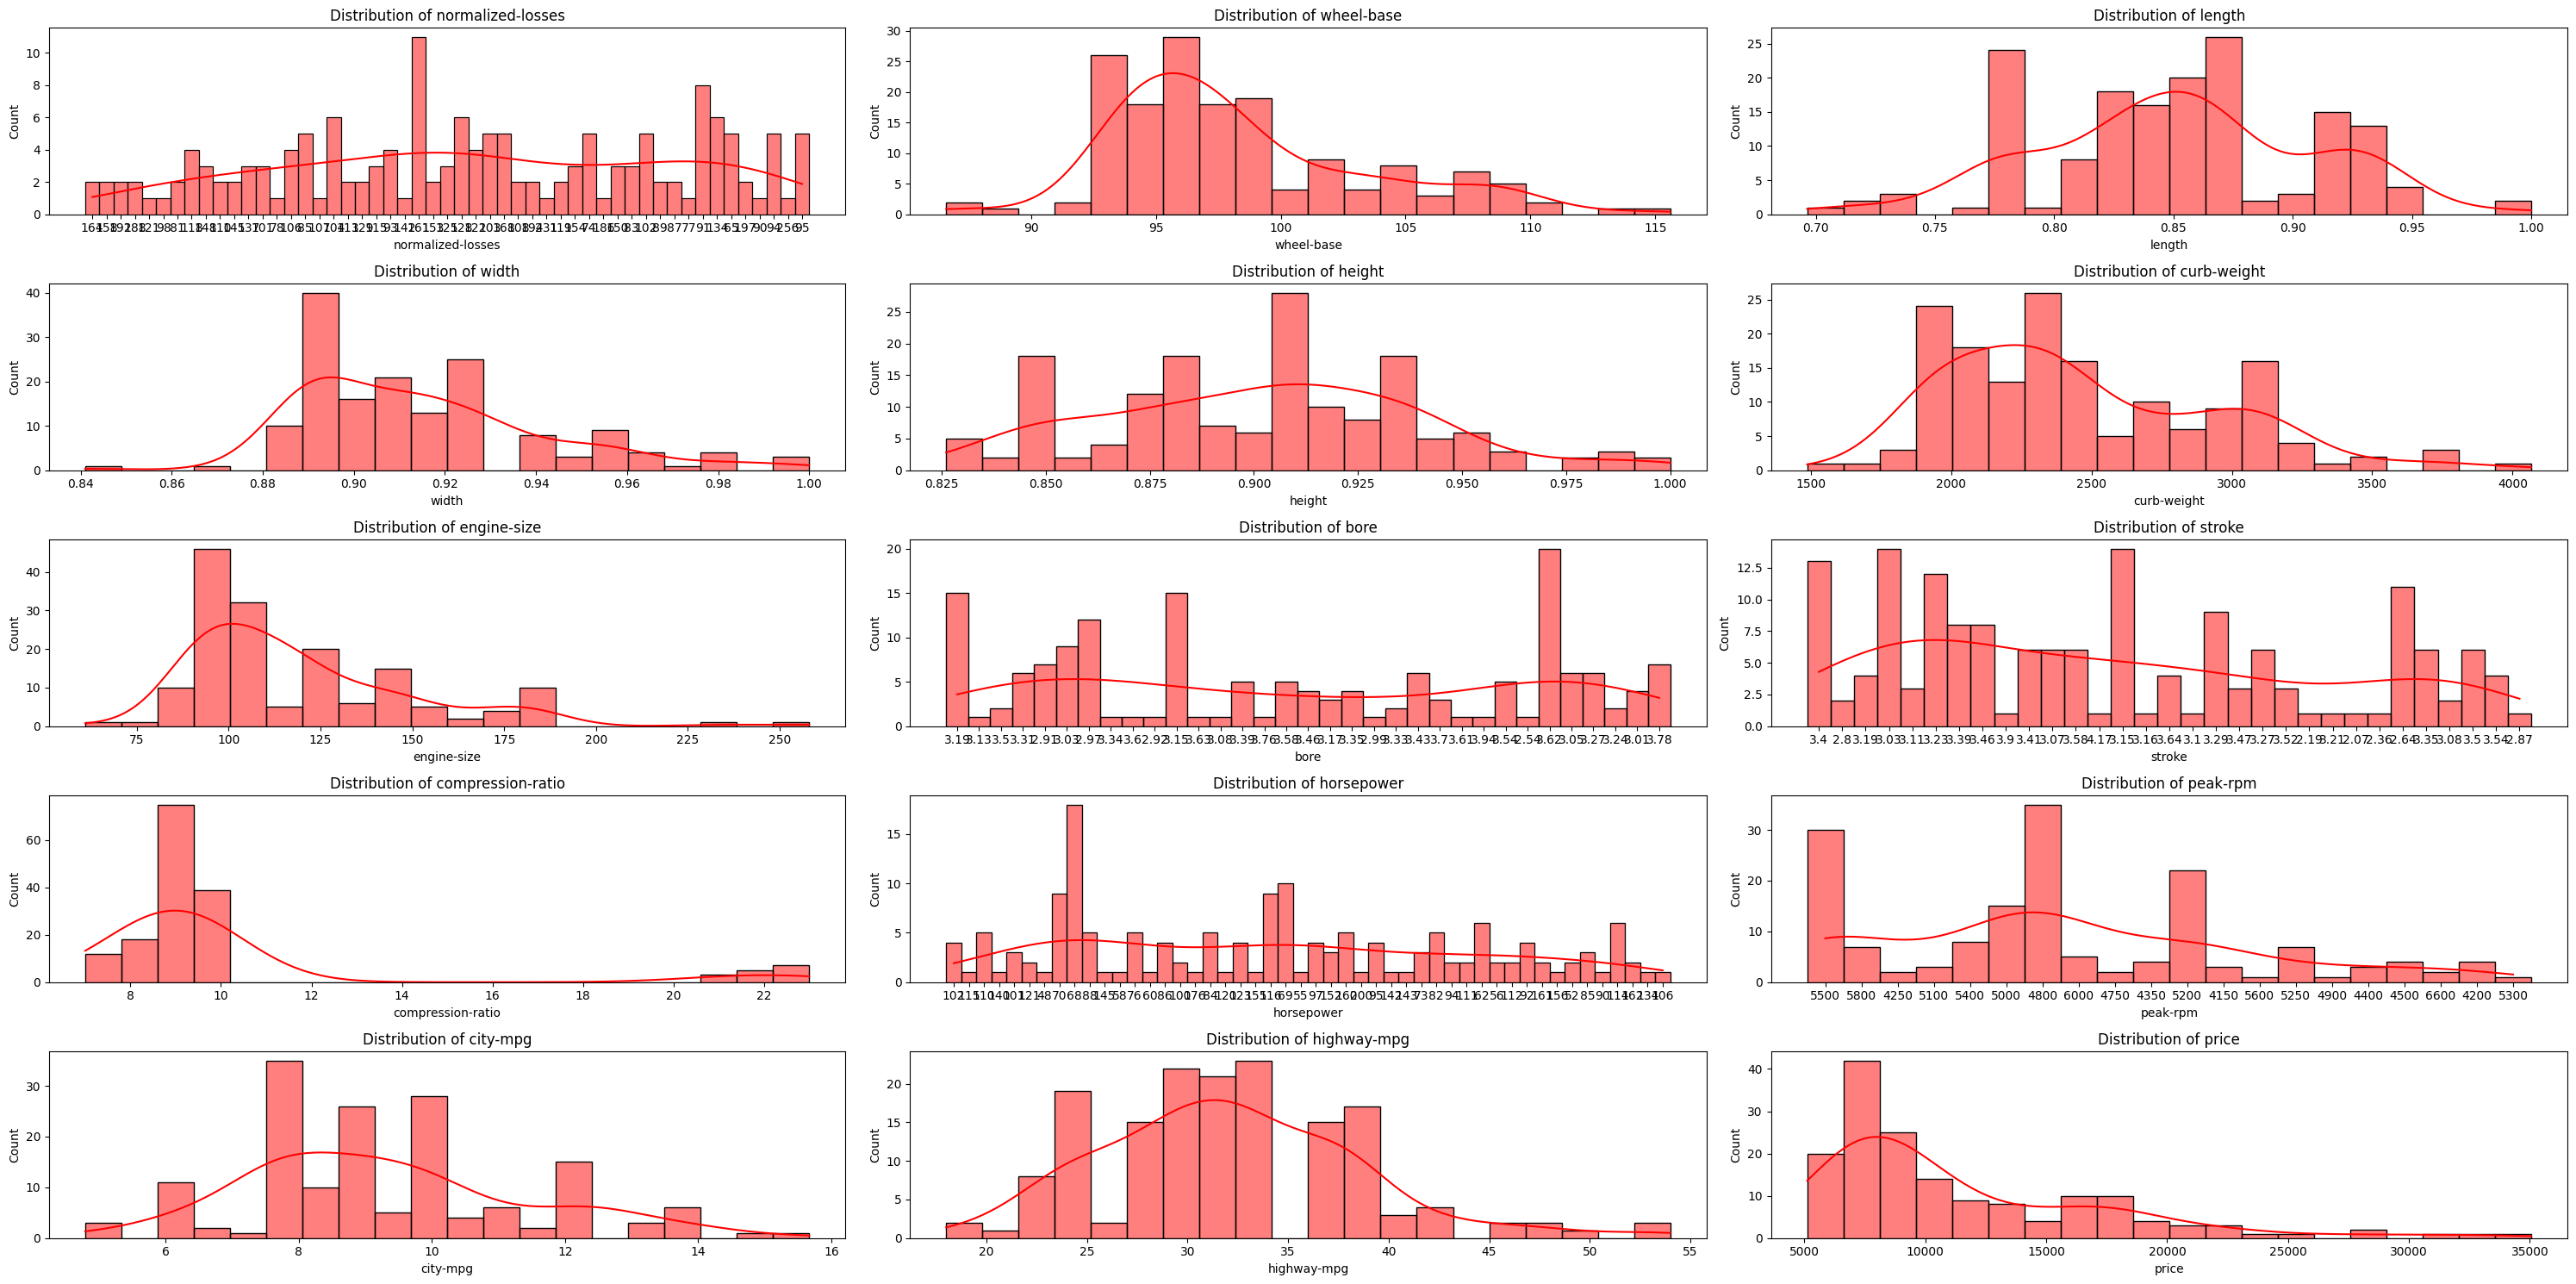

In [24]:
numerical_features = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                      'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                      'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

plt.figure(figsize=(30,15))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(5,3,i)
    sns.histplot(data[col].dropna(), kde=True, bins=20, color='red')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [25]:
numerical_features = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                      'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                      'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']
data.replace('?', np.nan, inplace=True)

# Drop rows with any NaN values
data = data.dropna();

CO-RELATIONS

RED MEANS POSITIVE RELATION,
BLUE MEANS NEGATIVE RELATION


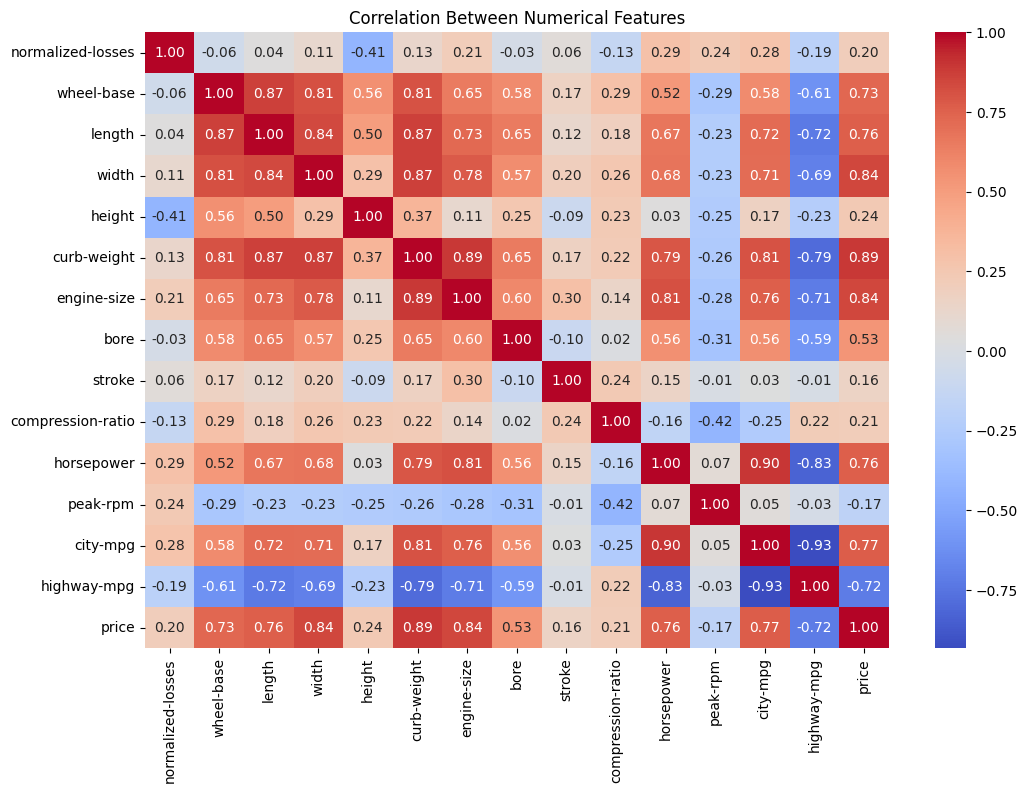

In [14]:
plt.figure(figsize=(12,8))
corr = data[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()

PRICE BASED MPG 
DOT REPRESENT CARS 
COLOR REPRESENT BODY TYPE

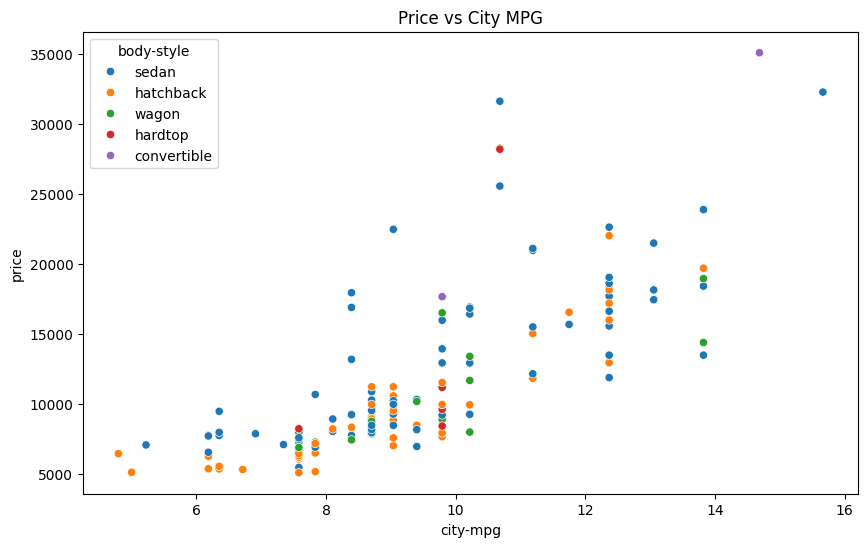

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='city-mpg', y='price', hue='body-style', data=data, palette='tab10')
plt.title("Price vs City MPG")
plt.show()

HOW MANY CARS HAVE DISTRIBUTED ACCORDING TO PRICE

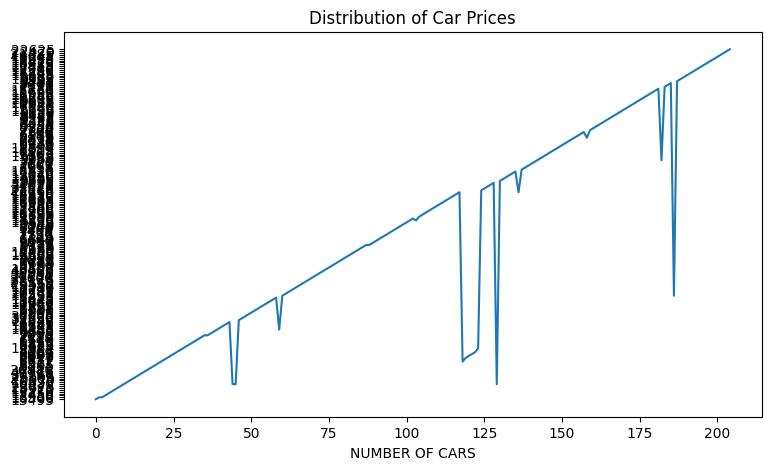

In [16]:
# Histogram of car prices
plt.figure(figsize=(9,5))
plt.plot(df['price'])
plt.title("Distribution of Car Prices")
plt.xlabel('NUMBER OF CARS')
plt.ylabel('')
plt.show()


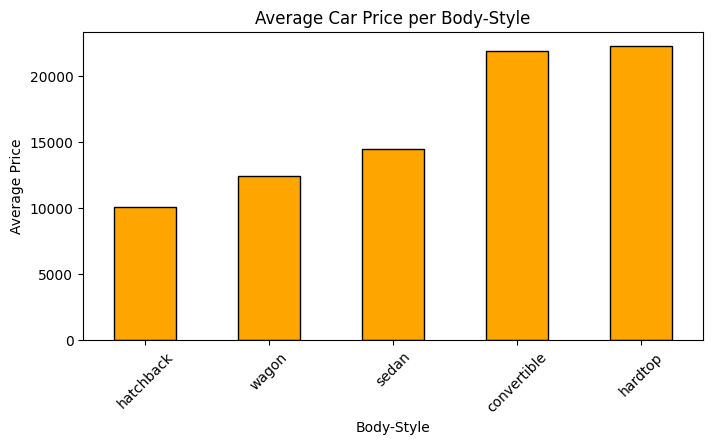

In [17]:

df['price'] = pd.to_numeric(df['price'], errors='coerce')

#Fill NaN values with mean
df['price'] = df['price'].fillna(df['price'].mean())

avg_price_body = df.groupby('body-style')['price'].mean().sort_values()

# Plotting the bar chart
plt.figure(figsize=(8,4))
avg_price_body.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Average Car Price per Body-Style")
plt.xlabel("Body-Style")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()


                     price  horsepower
drive-wheels                          
rwd           19671.422755  133.697368
4wd           10570.569928   95.333333
fwd            9310.818823   86.279269


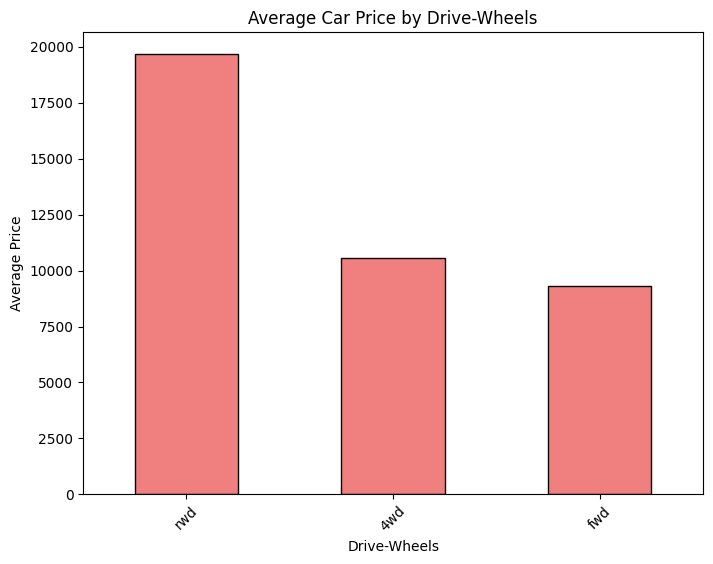

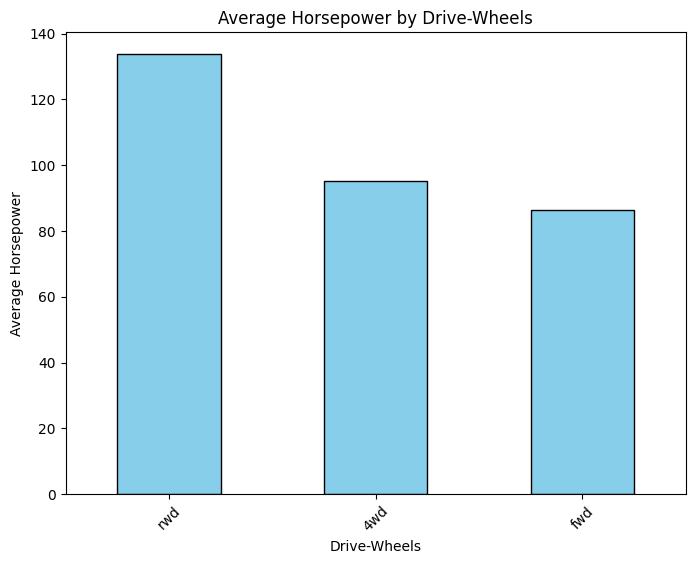

In [18]:

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Fill NaN values with mean
df['price'] = df['price'].fillna(df['price'].mean())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

# Group by 'drive-wheels' and calculate average price and horsepower
grouped_drive = df.groupby('drive-wheels')[['price', 'horsepower']].mean()

# Sort by price for clarity
grouped_drive = grouped_drive.sort_values('price', ascending=False)

# Show the results
print(grouped_drive)

# Plotting the bar chart for average price per drive-wheel type
plt.figure(figsize=(8,6))
grouped_drive['price'].plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Average Car Price by Drive-Wheels")
plt.xlabel("Drive-Wheels")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

# Optional: Plotting average horsepower per drive-wheel type
plt.figure(figsize=(8,6))
grouped_drive['horsepower'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Horsepower by Drive-Wheels")
plt.xlabel("Drive-Wheels")
plt.ylabel("Average Horsepower")
plt.xticks(rotation=45)
plt.show()


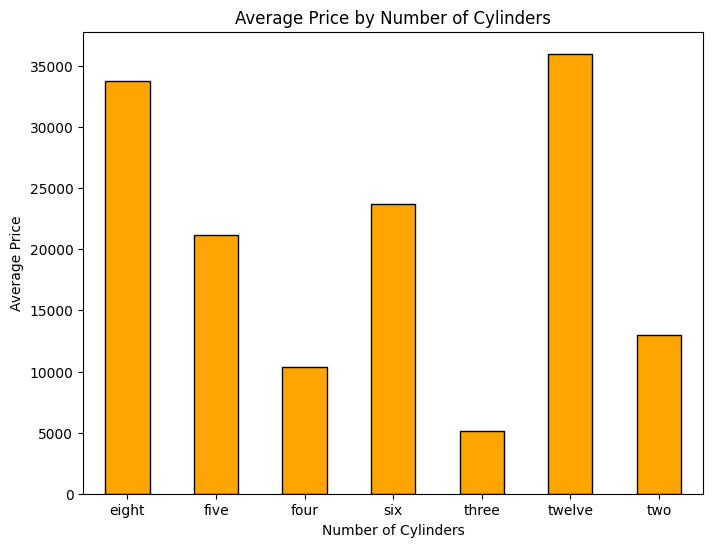

In [19]:

#Plot average price per number of cylinders
cylinder_group = df.groupby('num-of-cylinders', as_index=False)['price'].mean()
cylinder_group.set_index('num-of-cylinders', inplace=True)

plt.figure(figsize=(8,6))
cylinder_group['price'].plot(kind='bar', color='orange', edgecolor='black')
plt.title("Average Price by Number of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Average Price")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()


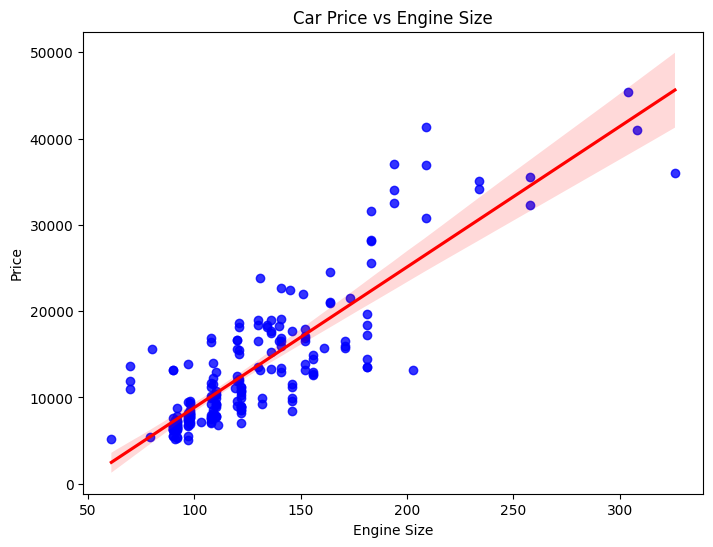

In [20]:
plt.figure(figsize=(8,6))
sns.regplot(x='engine-size', y='price', data=df, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title("Car Price vs Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

            city-mpg  highway-mpg
fuel-type                        
diesel      8.108976    34.750000
gas        10.148504    30.318919


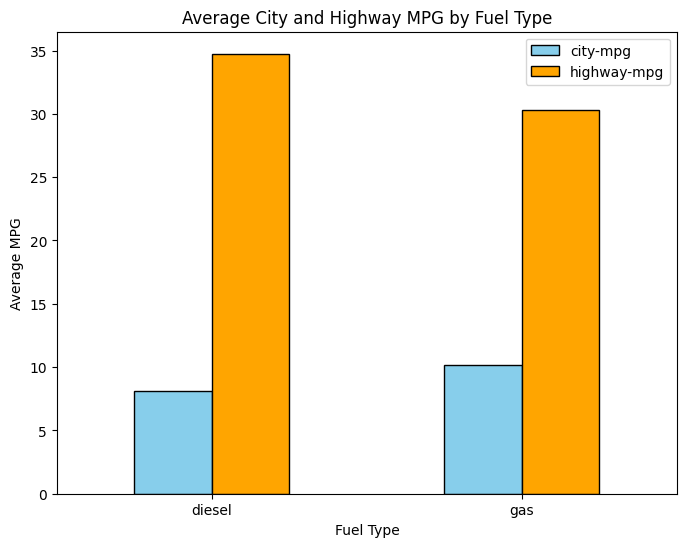

In [21]:

mpg_avg = df.groupby('fuel-type')[['city-mpg','highway-mpg']].mean()
print(mpg_avg)

# Plotting average MPG by fuel-type
mpg_avg.plot(kind='bar', figsize=(8,6), color=['skyblue','orange'], edgecolor='black')
plt.title("Average City and Highway MPG by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average MPG")
plt.xticks(rotation=0)
plt.show()